# Contrastive false negatives in ragged plankton taxonomy

Standard image–text contrastive loss (InfoNCE) treats **every off-diagonal pair in the batch as a negative** — it assumes any two samples that aren't the matched pair are unrelated. In clade-imbalanced plankton data this assumption is badly violated: a batch is full of samples from the *same* lineage (dozens of copepods, diatoms, ...), so the loss actively pushes apart images that should be aligned to the same text.

This notebook walks through it on **real data** and a **trained checkpoint**:
1. Pull a real training batch and show it is dominated by a few clades.
2. Find a concrete same-class pair and show standard CL treats it as a negative.
3. Build the false-negative mask (`--cl-mask same`) and show which cells it suppresses.
4. Show the geometric harm on the trained model: same-class images that CL was repelling.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, torch, collections
from datasets import load_from_disk
from hyperbolic_plankton.data import RANKS, HFTaxonomyDataset
from hyperbolic_plankton.train import TaxonomyCollator
from hyperbolic_plankton.loss import _dense_ids, _false_negative_mask
import hyperbolic_plankton.lorentz as L

CACHE = '/scratch/daniela/planktonzilla_cache/plankton'
SPLIT = '/scratch/daniela/hyperbolic_plankton_splits'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cuda


## 1. A real training batch is dominated by a few clades

We draw a B=128 batch the way training does, and look at the `full` lineage strings (what CL aligns each image to).

In [2]:
cache = load_from_disk(CACHE)
train_idx = np.load(f'{SPLIT}/train_idx.npy')
B = 128
sel = np.random.default_rng(0).choice(train_idx, size=B, replace=False)
ds = HFTaxonomyDataset(cache.select(sorted(sel.tolist())))
items = [ds[i] for i in range(len(ds))]
fulls = [it['taxonomy']['full'] for it in items]

# class = full lineage string; clade = first 3 ranks (kingdom phylum class)
clade = [' '.join(f.split()[:3]) for f in fulls]
cc = collections.Counter(clade)
print('Top clades in this batch (clade : #samples):')
for c, n in cc.most_common(6):
    print(f'  {n:3d}   {c}')
print(f'\n{sum(1 for c in clade if cc[c] > 1)}/{B} samples share their clade with >=1 other sample')

Loading dataset from disk:   0%|          | 0/41 [00:00<?, ?it/s]

Top clades in this batch (clade : #samples):
   62   animalia arthropoda copepoda
   24   chromista heterokontophyta bacillariophyceae
    6   chromista myzozoa dinophyceae
    4   animalia chordata appendicularia
    4   animalia arthropoda
    4   animalia chordata thaliacea

120/128 samples share their clade with >=1 other sample


## 2. A concrete same-class pair that CL treats as a negative

Find two samples with the **identical** `full` lineage. Standard InfoNCE puts image_i vs text_j (j != i) in the denominator as a negative — so it pushes image_i *away* from text_j even though text_j is image_i's own class.

In [3]:
# find the first identical-lineage pair
by_full = collections.defaultdict(list)
for i, f in enumerate(fulls):
    by_full[f].append(i)
dup = next(idxs for idxs in by_full.values() if len(idxs) > 1)
i, j = dup[0], dup[1]
print(f'sample {i} lineage: {fulls[i]}')
print(f'sample {j} lineage: {fulls[j]}')
print(f'\nIdentical lineage? {fulls[i] == fulls[j]}')
print(f'In standard CL, (image_{i}, text_{j}) is a NEGATIVE pair — the loss pushes them apart,')
print('even though they are literally the same class. This is a false negative.')

sample 2 lineage: animalia arthropoda copepoda cyclopoida oncaeidae
sample 114 lineage: animalia arthropoda copepoda cyclopoida oncaeidae

Identical lineage? True
In standard CL, (image_2, text_114) is a NEGATIVE pair — the loss pushes them apart,
even though they are literally the same class. This is a false negative.


In [4]:
# how many false negatives total in this batch?
def relation_counts(fulls):
    B = len(fulls); toks = [f.split() for f in fulls]
    same = prefix = 0; pairs = 0
    for a in range(B):
        for b in range(B):
            if a == b: continue
            pairs += 1
            if fulls[a] == fulls[b]: same += 1; continue
            k = min(len(toks[a]), len(toks[b]))
            if toks[a][:k] == toks[b][:k] and len(toks[a]) != len(toks[b]): prefix += 1
    return pairs, same, prefix

pairs, same, prefix = relation_counts(fulls)
print(f'off-diagonal negative pairs:      {pairs}')
print(f'  same-class (true positive!):    {same:5d}  ({100*same/pairs:.2f}%)')
print(f'  ancestor/prefix (lineage rel.): {prefix:5d}  ({100*prefix/pairs:.2f}%)')

off-diagonal negative pairs:      16256
  same-class (true positive!):      718  (4.42%)
  ancestor/prefix (lineage rel.):  2556  (15.72%)


## 3. The mask: `--cl-mask same`

We map each sample's lineage to a dense class id, then build the `[B, B]` mask that suppresses same-class off-diagonal cells (keeping the matched diagonal). Suppressed cells get `-inf` logits before the cross-entropy, so they drop out of the negative set.

In [5]:
ids = _dense_ids(fulls, torch.device('cpu'))
mask = _false_negative_mask(ids, ids, rank=0)  # True = suppressed negative
print(f'class ids (first 16): {ids[:16].tolist()}')
print(f'total cells suppressed: {int(mask.sum())} of {B*B} (= the same-class false negatives)')

# show the row for our offending sample i: which columns get suppressed
supp = mask[i].nonzero().flatten().tolist()
print(f'\nsample {i} (class id {ids[i].item()}): suppressed negative columns = {supp}')
print(f'  these are the other samples with lineage "{fulls[i]}"')
print(f'  diagonal {i} kept as positive: {not mask[i, i].item()}')

class ids (first 16): [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 8, 8, 8, 8, 8, 8]
total cells suppressed: 718 of 16384 (= the same-class false negatives)

sample 2 (class id 2): suppressed negative columns = [114, 115, 116]
  these are the other samples with lineage "animalia arthropoda copepoda cyclopoida oncaeidae"
  diagonal 2 kept as positive: True


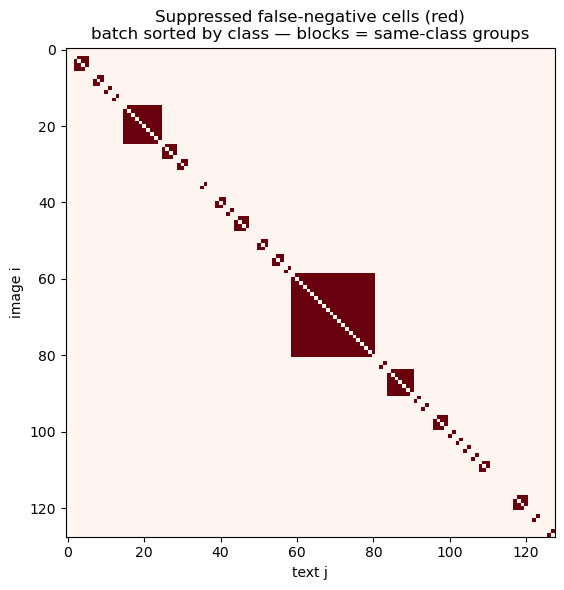

In [6]:
# visualize the mask (sorted by class so the same-class blocks are contiguous)
import matplotlib.pyplot as plt
order = np.argsort(ids.numpy(), kind='stable')
m_sorted = mask.numpy()[np.ix_(order, order)]
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(m_sorted, cmap='Reds', interpolation='nearest')
ax.set_title('Suppressed false-negative cells (red)\nbatch sorted by class — blocks = same-class groups')
ax.set_xlabel('text j'); ax.set_ylabel('image i')
plt.tight_layout(); plt.show()

## 4. The geometric harm, on the trained model

Load a trained checkpoint and encode the batch. For our same-class pair, standard CL was pushing image_i away from text_j. We show what the loss "wants": the contrastive gradient direction on image_i from that false-negative cell — it points image_i *away* from its own class's text.

In [7]:
from hyperbolic_plankton.model import HyperbolicCLIP
from hyperbolic_plankton.lora import apply_lora
from hyperbolic_plankton.loss import _deepest_text

CKPT = '/scratch/daniela/hyperbolic_plankton_ckpts/planktonzilla_uncha_freecurv_leak0.1_tau0.7_lamu0.5_it20000.pt'
model = HyperbolicCLIP(backbone='bioclip')
model = apply_lora(model, r=128, alpha=128)
sd = torch.load(CKPT, map_location='cpu')
model.load_state_dict(sd.get('model', sd), strict=False)
model.to(device).eval()
curv = model.curvature
print(f'loaded it20000, curv={curv.item():.3f}')

pix, tax, _ = TaxonomyCollator(model.preprocess)(items)
with torch.no_grad():
    img = model.encode_image(pix.to(device))
    cum = model.encode_taxonomy(tax)
    deepest, _ = _deepest_text(cum, RANKS)
print('encoded batch:', img.shape, deepest.shape)

loaded it20000, curv=0.549


encoded batch: torch.Size([128, 512]) torch.Size([128, 512])


In [8]:
# Hyperbolic distance image_i -> its own text vs -> the same-class sibling text_j.
# They should be CLOSE (same class), but standard CL's negative term pushes d(img_i, text_j) UP.
d_self = L.pairwise_dist(img[i:i+1], deepest[i:i+1], curv).item()
d_sib  = L.pairwise_dist(img[i:i+1], deepest[j:j+1], curv).item()

# a genuine negative (different class) for comparison
neg = next(k for k in range(B) if ids[k] != ids[i])
d_neg = L.pairwise_dist(img[i:i+1], deepest[neg:neg+1], curv).item()

print(f'd(image_{i}, its own text)            = {d_self:.3f}')
print(f'd(image_{i}, SAME-class sibling text) = {d_sib:.3f}   <- CL treats this as a negative to push UP')
print(f'd(image_{i}, different-class text)    = {d_neg:.3f}   <- a genuine negative')
print()
print('The same-class sibling sits about as close as the matched text — it is NOT a negative.')
print('Masking it (--cl-mask same) stops the loss from repelling them.')

d(image_2, its own text)            = 0.349
d(image_2, SAME-class sibling text) = 0.349   <- CL treats this as a negative to push UP
d(image_2, different-class text)    = 0.946   <- a genuine negative

The same-class sibling sits about as close as the matched text — it is NOT a negative.
Masking it (--cl-mask same) stops the loss from repelling them.


In [9]:
# Make the harm concrete: contrastive loss WITH vs WITHOUT masking on this batch,
# and the gradient magnitude the false negatives contribute.
from hyperbolic_plankton.loss import hyperbolic_contrastive_loss
scale = model.logit_scale.exp().detach()

img_g = img.clone().requires_grad_()
loss_unmasked = hyperbolic_contrastive_loss(img_g, deepest, curv, scale)
g_unmasked = torch.autograd.grad(loss_unmasked, img_g, retain_graph=True)[0]

loss_masked = hyperbolic_contrastive_loss(img_g, deepest, curv, scale, class_ids=ids.to(device))
g_masked = torch.autograd.grad(loss_masked, img_g)[0]

print(f'loss unmasked: {loss_unmasked.item():.4f}')
print(f'loss masked:   {loss_masked.item():.4f}')
print(f'\nper-sample gradient-norm change |g_unmasked| - |g_masked| (top 5 samples most affected):')
delta = g_unmasked.norm(dim=-1) - g_masked.norm(dim=-1)
for k in delta.abs().topk(5).indices.tolist():
    n_same = int((ids == ids[k]).sum()) - 1
    print(f'  sample {k:3d}: Δ|grad|={delta[k]:+.4f}  ({n_same} same-class siblings in batch)')
print('\nSamples with same-class siblings see the largest gradient change — those are exactly')
print('the false-negative forces that masking removes.')

loss unmasked: 1.7992
loss masked:   1.0067

per-sample gradient-norm change |g_unmasked| - |g_masked| (top 5 samples most affected):


  sample  83: Δ|grad|=-0.1416  (2 same-class siblings in batch)
  sample  82: Δ|grad|=-0.1236  (2 same-class siblings in batch)
  sample  80: Δ|grad|=-0.1210  (3 same-class siblings in batch)
  sample  55: Δ|grad|=-0.1096  (0 same-class siblings in batch)
  sample  57: Δ|grad|=-0.1024  (9 same-class siblings in batch)

Samples with same-class siblings see the largest gradient change — those are exactly
the false-negative forces that masking removes.


## Takeaway

In clade-imbalanced plankton batches, a large fraction of "negatives" are same-class (true positives) or lineage relatives. Standard InfoNCE repels them, corrupting the very intra-clade structure that taxonomic / unseen-species generalization depends on. `--cl-mask same` removes the clearest offenders (identical-lineage pairs) by dropping them from the negative set, at no extra model cost.

Open: the ancestor/prefix relatives (a species pushed off its own order's text) are *not* masked by `same` — whether to also mask those is a design choice (a species genuinely differs from its order), measured separately.